<img src="https://dt99qig9iutro.cloudfront.net/production/images/header-logo-green.png" alt="QuantInsti Logo">

<h1 style="text-align:center;"> Python Tutorial: DMP-01 Tutorial Session </h1>

<h2 style="text-align:center;"> Instructor: Manusha Rao </h2>

<h4 style="text-align:center;"> Author: Jay Parmar, Modified by: Manusha Rao </h4>

### Today's Agenda
- Libraries and fetching data
    - Using yfinance
    - Importing from csv files
- Steps in vectorized backtesting of a typical strategy
- Simple returns vs log returns: which one to use?
- Optional: 
    - Vectorized backtesting vs event driven backtesting (using for-loops)

### About today's session
- Priority to doubts concerning material covered in the DMP-01
- Understanding building blocks of basic vectorized backtesting and a small sneak-peek into event-driven backtesting

### Libraries & Data Fetching

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import warnings

# Libraries needed for visualization
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
start_date = (2017, 1, 1)
end_date = (2020, 11, 30)

In [3]:
type(start_date)

tuple

In [4]:
start_date = '2017-1-1'
end_date = '2020-11-30'

In [5]:
type(start_date)

str

In [6]:
# Create start and end date variables
start_date = dt.date(2017, 1, 1)
end_date = dt.date(2020, 11, 30)

In [7]:
type(start_date)

datetime.date

In [8]:
# Print start and end dates
print('Start date is', start_date)

print('End date is', end_date)

Start date is 2017-01-01
End date is 2020-11-30


In [9]:
# Using the yfinance library download NIFTY50 data
ticker = '^NSEI'  # the security for which we want the data
#df = yf.download(ticker, start=start_date, end=end_date)
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False, auto_adjust = False)

[*********************100%***********************]  1 of 1 completed


In [10]:
df


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400
...,...,...,...,...,...,...
2020-11-23,12926.450195,12926.450195,12968.849609,12825.700195,12960.299805,633100
2020-11-24,13055.150391,13055.150391,13079.099609,12978.000000,13002.599609,571900
2020-11-25,12858.400391,12858.400391,13145.849609,12833.650391,13130.000000,679000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 962 entries, 2017-01-02 to 2020-11-27
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  962 non-null    float64
 1   Close      962 non-null    float64
 2   High       962 non-null    float64
 3   Low        962 non-null    float64
 4   Open       962 non-null    float64
 5   Volume     962 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 52.6 KB


In [12]:
df.shape

(962, 6)

In [13]:
df.shape[1]

6

In [14]:
#df.shape can be used for iterating over the rows/columns of the dataframe
for i in range(df.shape[0]):
    print(df["Close"][i])

8179.5
8192.25
8190.5
8273.7998046875
8243.7998046875
8236.0498046875
8288.599609375
8380.650390625
8407.2001953125
8400.349609375
8412.7998046875
8398.0
8417.0
8435.099609375
8349.349609375
8391.5
8475.7998046875
8602.75
8641.25
8632.75
8561.2998046875
8716.400390625
8734.25
8740.9501953125
8801.0498046875
8768.2998046875
8769.0498046875
8778.400390625
8793.5498046875
8805.0498046875
8792.2998046875
8724.7001953125
8778.0
8821.7001953125
8879.2001953125
8907.849609375
8926.900390625
8939.5
8896.7001953125
8879.599609375
8945.7998046875
8899.75
8897.5498046875
8963.4501953125
8946.900390625
8924.2998046875
8927.0
8934.5498046875
9087.0
9084.7998046875
9153.7001953125
9160.0498046875
9126.849609375
9121.5
9030.4501953125
9086.2998046875
9108.0
9045.2001953125
9100.7998046875
9143.7998046875
9173.75
9173.75
9237.849609375
9265.150390625
9261.9501953125
9198.2998046875
9181.4501953125
9237.0
9203.4501953125
9150.7998046875
9139.2998046875
9105.150390625
9103.5
9136.400390625
9119.40039062

In [15]:
df.head(6)

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400
2017-01-09,8236.049805,8236.049805,8263.000000,8227.750000,8259.349609,99100


In [16]:
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [17]:
df

,Close,High,Low,Open,Volume
Date,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400
...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 962 entries, 2017-01-02 to 2020-11-27
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   962 non-null    float64
 1   High    962 non-null    float64
 2   Low     962 non-null    float64
 3   Open    962 non-null    float64
 4   Volume  962 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 45.1 KB


In [19]:
yf.download?

Signature:
yf.download(
    tickers,
    start=None,
    end=None,
    actions=False,
    threads=True,
    ignore_tz=None,
    group_by='column',
    auto_adjust=True,
    back_adjust=False,
    repair=False,
    keepna=False,
    progress=True,
    period=None,
    interval='1d',
    prepost=False,
    rounding=False,
    timeout=10,
    session=None,
    multi_level_index=True,
) -> Optional[pandas.core.frame.DataFrame]
Docstring:
Download yahoo tickers
:Parameters:
    tickers : str, list
        List of tickers to download
    period : str
        Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        Default: 1mo
        Either Use period parameter or use start and end
    interval : str
        Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        Intraday data cannot extend last 60 days
    start: str
        Download start date string (YYYY-MM-DD) or _datetime, inclusive.
        Default is 99 years ago
        E.g. for start="2020-01-01", the first dat

In [20]:
help(yf.download)

Help on function download in module yfinance.multi:

download(tickers, start=None, end=None, actions=False, threads=True, ignore_tz=None, group_by='column', auto_adjust=True, back_adjust=False, repair=False, keepna=False, progress=True, period=None, interval='1d', prepost=False, rounding=False, timeout=10, session=None, multi_level_index=True) -> Optional[pandas.core.frame.DataFrame]
    Download yahoo tickers
    :Parameters:
        tickers : str, list
            List of tickers to download
        period : str
            Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
            Default: 1mo
            Either Use period parameter or use start and end
        interval : str
            Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
            Intraday data cannot extend last 60 days
        start: str
            Download start date string (YYYY-MM-DD) or _datetime, inclusive.
            Default is 99 years ago
            E.g. for start="2020-01-01", the 

Note: If downloading intraday data from Yahoo, the requested range must be within the last 60 days.

In [21]:
intraday_data = yf.download('EURUSD=X', interval='5m', period='60d', multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [22]:
intraday_data

,Close,High,Low,Open,Volume
Datetime,,,,,
2026-03-05 00:00:00+00:00,1.163873,1.163873,1.163603,1.163738,0
2026-03-05 00:05:00+00:00,1.164009,1.164009,1.163738,1.163738,0
2026-03-05 00:10:00+00:00,1.164009,1.164009,1.164009,1.164009,0
2026-03-05 00:15:00+00:00,1.164415,1.164415,1.164009,1.164009,0
2026-03-05 00:20:00+00:00,1.164687,1.164687,1.164551,1.164551,0
...,...,...,...,...,...
2026-05-27 08:05:00+00:00,1.164551,1.164551,1.164415,1.164551,0
2026-05-27 08:10:00+00:00,1.164822,1.164958,1.164687,1.164958,0
2026-05-27 08:15:00+00:00,1.164687,1.165230,1.164687,1.165230,0


In [23]:
intraday_data.index = intraday_data.index.tz_convert('Asia/Kolkata')

In [24]:
intraday_data

,Close,High,Low,Open,Volume
Datetime,,,,,
2026-03-05 05:30:00+05:30,1.163873,1.163873,1.163603,1.163738,0
2026-03-05 05:35:00+05:30,1.164009,1.164009,1.163738,1.163738,0
2026-03-05 05:40:00+05:30,1.164009,1.164009,1.164009,1.164009,0
2026-03-05 05:45:00+05:30,1.164415,1.164415,1.164009,1.164009,0
2026-03-05 05:50:00+05:30,1.164687,1.164687,1.164551,1.164551,0
...,...,...,...,...,...
2026-05-27 13:35:00+05:30,1.164551,1.164551,1.164415,1.164551,0
2026-05-27 13:40:00+05:30,1.164822,1.164958,1.164687,1.164958,0
2026-05-27 13:45:00+05:30,1.164687,1.165230,1.164687,1.165230,0


In [25]:
import pytz
#!pip install pytz
 
print('the supported timezones by the pytz module:',
      pytz.all_timezones, '\n')

the supported timezones by the pytz module: ['Africa/Abidjan', 'Africa/Accra', 'Africa/Addis_Ababa', 'Africa/Algiers', 'Africa/Asmara', 'Africa/Asmera', 'Africa/Bamako', 'Africa/Bangui', 'Africa/Banjul', 'Africa/Bissau', 'Africa/Blantyre', 'Africa/Brazzaville', 'Africa/Bujumbura', 'Africa/Cairo', 'Africa/Casablanca', 'Africa/Ceuta', 'Africa/Conakry', 'Africa/Dakar', 'Africa/Dar_es_Salaam', 'Africa/Djibouti', 'Africa/Douala', 'Africa/El_Aaiun', 'Africa/Freetown', 'Africa/Gaborone', 'Africa/Harare', 'Africa/Johannesburg', 'Africa/Juba', 'Africa/Kampala', 'Africa/Khartoum', 'Africa/Kigali', 'Africa/Kinshasa', 'Africa/Lagos', 'Africa/Libreville', 'Africa/Lome', 'Africa/Luanda', 'Africa/Lubumbashi', 'Africa/Lusaka', 'Africa/Malabo', 'Africa/Maputo', 'Africa/Maseru', 'Africa/Mbabane', 'Africa/Mogadishu', 'Africa/Monrovia', 'Africa/Nairobi', 'Africa/Ndjamena', 'Africa/Niamey', 'Africa/Nouakchott', 'Africa/Ouagadougou', 'Africa/Porto-Novo', 'Africa/Sao_Tome', 'Africa/Timbuktu', 'Africa/Tripoli

In [26]:
intraday_data.shape

(16741, 5)

In [27]:
# Set display options
#pd.set_option('display.max_rows', None)    # Show all rows
#pd.set_option('display.max_columns', None) # Show all columns

#### Writing data to csv files and fetching data from csv files

In [28]:
ticker = "^NSEI"
df1 = yf.download(ticker, start=start_date, end=end_date, auto_adjust = False, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [29]:
df1

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400
...,...,...,...,...,...,...
2020-11-23,12926.450195,12926.450195,12968.849609,12825.700195,12960.299805,633100
2020-11-24,13055.150391,13055.150391,13079.099609,12978.000000,13002.599609,571900
2020-11-25,12858.400391,12858.400391,13145.849609,12833.650391,13130.000000,679000


In [30]:
# Write the data to a csv file
df1.to_csv('DMP_01_tutorial_data_nse_saved.csv')

In [31]:
# Fetch data from a csv file
df1=pd.read_csv('DMP_01_tutorial_data_nse_saved.csv')

In [32]:
df1

,Date,Adj Close,Close,High,Low,Open,Volume
0,2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
1,2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2,2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
3,2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
4,2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400
...,...,...,...,...,...,...,...
957,2020-11-23,12926.450195,12926.450195,12968.849609,12825.700195,12960.299805,633100
958,2020-11-24,13055.150391,13055.150391,13079.099609,12978.000000,13002.599609,571900
959,2020-11-25,12858.400391,12858.400391,13145.849609,12833.650391,13130.000000,679000
960,2020-11-26,12987.000000,12987.000000,13018.000000,12790.400391,12906.450195,549800


In [33]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       962 non-null    object 
 1   Adj Close  962 non-null    float64
 2   Close      962 non-null    float64
 3   High       962 non-null    float64
 4   Low        962 non-null    float64
 5   Open       962 non-null    float64
 6   Volume     962 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 52.7+ KB


In [34]:
import os
os.getcwd()

'C:\\Users\\maili\\DMP 01 tutorial session'

In [35]:
# csv file is saved in the current working directory
df1_from_csv = pd.read_csv("DMP_01_tutorial_data_nse_saved.csv")
df1_from_csv.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
1,2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2,2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
3,2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
4,2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400


In [36]:
# When the file is not stored in the current working directory
#df_from_csv = pd.read_csv(r'C:\Users\academy\DMP-01 tutorial session\DMP_01_tutorial_data_nse_saved.csv')

In [37]:
df1_from_csv

,Date,Adj Close,Close,High,Low,Open,Volume
0,2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
1,2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2,2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
3,2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
4,2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400
...,...,...,...,...,...,...,...
957,2020-11-23,12926.450195,12926.450195,12968.849609,12825.700195,12960.299805,633100
958,2020-11-24,13055.150391,13055.150391,13079.099609,12978.000000,13002.599609,571900
959,2020-11-25,12858.400391,12858.400391,13145.849609,12833.650391,13130.000000,679000
960,2020-11-26,12987.000000,12987.000000,13018.000000,12790.400391,12906.450195,549800


In [38]:
df1_from_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       962 non-null    object 
 1   Adj Close  962 non-null    float64
 2   Close      962 non-null    float64
 3   High       962 non-null    float64
 4   Low        962 non-null    float64
 5   Open       962 non-null    float64
 6   Volume     962 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 52.7+ KB


In [39]:
df1_from_csv = pd.read_csv("DMP_01_tutorial_data_nse_saved.csv", index_col="Date")
df1_from_csv.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2017-01-02,8179.500000,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8243.799805,8306.849609,8233.250000,8281.849609,139400


In [40]:
df1_from_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 2017-01-02 to 2020-11-27
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  962 non-null    float64
 1   Close      962 non-null    float64
 2   High       962 non-null    float64
 3   Low        962 non-null    float64
 4   Open       962 non-null    float64
 5   Volume     962 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 52.6+ KB


In [41]:
df1_from_csv = pd.read_csv("DMP_01_tutorial_data_nse_saved.csv", index_col = "Date", parse_dates=True)

In [42]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'list[HashableT] | Callable[[Hashable], bool] | None' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Sequence[str] | Mapping[str, Sequence[str]] | None' = None,
    keep_default_na: 'bool' = True,
    n

In [43]:
df1_from_csv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 962 entries, 2017-01-02 to 2020-11-27
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  962 non-null    float64
 1   Close      962 non-null    float64
 2   High       962 non-null    float64
 3   Low        962 non-null    float64
 4   Open       962 non-null    float64
 5   Volume     962 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 52.6 KB


### Element-wise Operation & Vectorized Operation

In [44]:
# Define a list
number_list = [1, 2, 11, 22, 5, 6, 8]

In [45]:
type(number_list)

list

In [46]:
number_list * 3

[1, 2, 11, 22, 5, 6, 8, 1, 2, 11, 22, 5, 6, 8, 1, 2, 11, 22, 5, 6, 8]

In [47]:
number_list_to_array=np.array(number_list)

In [48]:
number_list_to_array

array([ 1,  2, 11, 22,  5,  6,  8])

In [49]:
number_list_to_array * 3

array([ 3,  6, 33, 66, 15, 18, 24])

In [50]:
for value in number_list:
    print(value*3)

3
6
33
66
15
18
24


In [51]:
# Iterate through each element in the list and perform the given operation
for i in number_list:
    print(i * 8)

8
16
88
176
40
48
64


In [52]:
# Perform the same operation using vectorized approach
number_array = np.array([1, 2, 11, 22, 5, 6, 8])

In [53]:
type(number_array)

numpy.ndarray

In [54]:
number_array * 8

array([  8,  16,  88, 176,  40,  48,  64])

## What is Vectorization?

![What is Vectorization?](https://lappweb.in2p3.fr/~paubert/ASTERICS_HPC/images/vectorization.png "Vectorized Operation")

## Steps in Vectorized Backtesting of a Typical Strategy

1. Strategy/Idea
2. Data
3. Indicators / Alpha Source
4. Signals
5. Positions
6. Returns
7. Analysis

#### 1) Example Strategy/Idea: ***The Moving Average Crossover Strategy (Long-short)***

We have two MA filters viz. the shorter lookback period MA (henceforth referred to as `SMA`) and the longer lookback period MA (henceforth referred to as `LMA`). We go long at the first instance when the `SMA` exceeds the `LMA`. Similarly, we go short at the first instance when the `LMA`  exceeds the `SMA`.

Our trading rules can be stated as:
- Go long when `SMA` > `LMA` on a given day <b>and</b> `SMA` < `LMA` on the previous day
- Go short when `SMA` < `LMA` on a given day <b>and</b> `SMA` > `LMA` on the previous day

**Note:** Basic assumption is that we trade/take positions at the close of the trading day.

#### 2) Data: 

In [55]:
ticker

'^NSEI'

In [56]:
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index= False)
data = df.copy()

[*********************100%***********************]  1 of 1 completed


In [57]:
ticker

'^NSEI'

In [58]:
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400


#### 3) Indicators:

In [59]:
data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400


In [60]:
data

,Close,High,Low,Open,Volume
Date,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400
...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000


<Axes: xlabel='Date'>

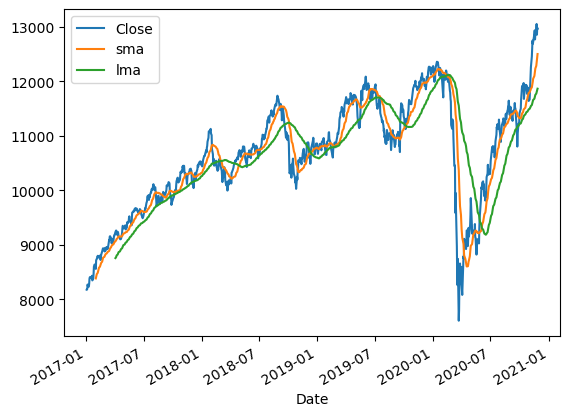

In [61]:
# Define lookback periods for sma and lma
sma_lookback = 21
lma_lookback = 63

# Calculate SMA and LMA indicators
data['sma'] = data['Close'].rolling(window=sma_lookback).mean()

data['lma'] = data['Close'].rolling(window=lma_lookback).mean()

# Plot SMA, LMA & Adj Close prices
data[['Close', 'sma', 'lma']].plot()

In [62]:
data


,Close,High,Low,Open,Volume,sma,lma
Date,,,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300,NaN,NaN
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300,NaN,NaN
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400,NaN,NaN
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100,NaN,NaN
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400,NaN,NaN
...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210


In [63]:
import plotly.io as pio
import plotly.express as px

pio.renderers.default = "browser"

fig = px.line(data, y=['Close', 'sma', 'lma'])
fig.show()

Short = -1

Long = 1

No Position = 0

In [64]:
data

,Close,High,Low,Open,Volume,sma,lma
Date,,,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300,NaN,NaN
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300,NaN,NaN
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400,NaN,NaN
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100,NaN,NaN
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400,NaN,NaN
...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210


In [65]:
# Create new columns to store prev days value
data['sma_prev_day'] = data['sma'].shift(1)
data['lma_prev_day'] = data['lma'].shift(1)

In [66]:
# Verify the data
data

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day
Date,,,,,,,,,
2017-01-02,8179.500000,8212.000000,8133.799805,8210.099609,118300,NaN,NaN,NaN,NaN
2017-01-03,8192.250000,8219.099609,8148.600098,8196.049805,127300,NaN,NaN,NaN,NaN
2017-01-04,8190.500000,8218.500000,8180.899902,8202.650391,132400,NaN,NaN,NaN,NaN
2017-01-05,8273.799805,8282.650391,8223.700195,8226.650391,159100,NaN,NaN,NaN,NaN
2017-01-06,8243.799805,8306.849609,8233.250000,8281.849609,139400,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595


In [67]:
data.shape

(962, 9)

In [68]:
# Getting rid of rows with NaN values
data.dropna(inplace=True)

In [69]:
data

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day
Date,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912
...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595


In [70]:
data.head()

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day
Date,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912


In [71]:
data.shape

(899, 9)

In [72]:
data

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day
Date,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912
...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595


#### 4) Signals:

In [73]:
fig = px.line(data, y=['sma', 'lma'])
fig.show()

In [74]:
# Annotating the signals using arrows

# Plotting moving averages
fig = px.line(data, y=['sma', 'lma'])

# Find crossover points
crossovers = []
for i in range(1, len(data)):
    if data['sma'][i] > data['lma'][i] and data['sma'][i-1] <= data['lma'][i-1]:
        crossovers.append(data.index[i])
    elif data['sma'][i] < data['lma'][i] and data['sma'][i-1] >= data['lma'][i-1]:
        crossovers.append(data.index[i])

# Annotate crossover points with arrows
for crossover in crossovers:
    sma_value = data.loc[crossover]['sma']
    lma_value = data.loc[crossover]['lma']
    if data['sma'][crossover] > data['lma'][crossover]:
        text = 'Bullish Crossover'
        y_offset = 0
        arrow_direction = -1
    else:
        text = 'Bearish Crossover'
        y_offset = -20
        arrow_direction = 1
    fig.add_shape(type='line', x0=crossover, y0=sma_value, x1=crossover, y1=lma_value,
                  line=dict(color='black', width=1, dash='dash'))
    fig.add_annotation(x=crossover, y=sma_value, text=text, showarrow=False,
                       font=dict(size=10), yshift=y_offset)
    fig.add_annotation(x=crossover, y=(sma_value + lma_value) / 2, text='', showarrow=True,
                       ax=arrow_direction * 20, ay=0,
                       arrowhead=2, arrowsize=1, arrowwidth=1)

# Show plot
fig.show()

In [75]:
# Annotating the signals using legends

# Plotting moving averages
fig = px.line(data, y=['sma', 'lma'])

# Find crossover points
crossovers = []
for i in range(1, len(data)):
    if data['sma'][i] > data['lma'][i] and data['sma'][i-1] <= data['lma'][i-1]:
        crossovers.append(data.index[i])
    elif data['sma'][i] < data['lma'][i] and data['sma'][i-1] >= data['lma'][i-1]:
        crossovers.append(data.index[i])

# Plotting crossover points
bullish_crossovers = data.loc[crossovers][data['sma'] > data['lma']]
bearish_crossovers = data.loc[crossovers][data['sma'] < data['lma']]
fig.add_scatter(x=bullish_crossovers.index, y=bullish_crossovers['sma'], mode='markers', name='Bullish Crossover', marker=dict(color='green',size=10))
fig.add_scatter(x=bearish_crossovers.index, y=bearish_crossovers['sma'], mode='markers', name='Bearish Crossover', marker=dict(color='red',size=10))

# Show plot
fig.show()

In [76]:
# Signals based on crossover logic
# Long = 1
# Short = -1
# Do nothing = 0

# Long crossover
todays_condition_for_long = data['sma'] > data['lma']
yesterdays_condition_for_long = data['sma_prev_day'] < data['lma_prev_day']

# Generate long signals
data['signal'] = np.where(todays_condition_for_long & yesterdays_condition_for_long, 1, 0)

In [77]:
data

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal
Date,,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027,0
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573,0
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941,0
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763,0
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912,0
...,...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0


In [78]:
data['signal'].value_counts()

signal
0    895
1      4
Name: count, dtype: int64

In [79]:
# Short Crossover
todays_condition_for_short = data['sma'] < data['lma']
yesterdays_condition_for_short = data['sma_prev_day'] > data['lma_prev_day']

# Generate short signals and carry forward long signals
data['signal'] = np.where(todays_condition_for_short &
                          yesterdays_condition_for_short, -1, data['signal'])

In [80]:
data['signal'].value_counts()

signal
 0    891
-1      4
 1      4
Name: count, dtype: int64

In [81]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=data.index, y=data['sma'], name='SMA'), secondary_y=False)
fig.add_trace(go.Scatter(x=data.index, y=data['lma'], name='LMA'), secondary_y=False)
fig.add_trace(go.Scatter(x=data.index, y=data['signal'], name='Signal'), secondary_y=True)

fig.show()

In [82]:
data


,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal
Date,,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027,0
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573,0
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941,0
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763,0
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912,0
...,...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0


#### 5) Positions:

In [83]:
data['position'] = data['signal'].replace(to_replace=0, method='ffill')

In [84]:
data['position'].value_counts()

position
 1    466
 0    226
-1    207
Name: count, dtype: int64

In [85]:
# To check if the strategy is working as planned
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=data.index, y=data['sma'], name='SMA'), secondary_y=False)
fig.add_trace(go.Scatter(x=data.index, y=data['lma'], name='LMA'), secondary_y=False)
fig.add_trace(go.Scatter(x=data.index, y=data['position'], name='Position'), secondary_y=True)

fig.show()

#### 6) Periodic Returns:

In [86]:
# 'Buy and hold' i.e. passive unrealized daily returns
data['bnh_returns'] = data['Close'].pct_change()

# Strategy returns(unrealized) series
data['strategy_returns'] = data['bnh_returns'] * data['position'].shift(2)

In [87]:
data


,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal,position,bnh_returns,strategy_returns
Date,,,,,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027,0,0,NaN,NaN
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573,0,0,-0.000345,NaN
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941,0,0,-0.006872,-0.000000
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763,0,0,-0.001832,-0.000000
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912,0,0,0.006050,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0,1,0.005241,0.005241
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0,1,0.009956,0.009956
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0,1,-0.015071,-0.015071


In [88]:
data


,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal,position,bnh_returns,strategy_returns
Date,,,,,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027,0,0,NaN,NaN
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573,0,0,-0.000345,NaN
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941,0,0,-0.006872,-0.000000
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763,0,0,-0.001832,-0.000000
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912,0,0,0.006050,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0,1,0.005241,0.005241
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0,1,0.009956,0.009956
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0,1,-0.015071,-0.015071


In [89]:
# Equity calculations
data['bnh_equity'] = np.cumprod(1 + data['bnh_returns'])
data['strategy_equity'] = np.cumprod(1 + data['strategy_returns'])

In [90]:
data

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal,position,bnh_returns,strategy_returns,bnh_equity,strategy_equity
Date,,,,,,,,,,,,,,,
2017-04-05,9265.150391,9273.900391,9215.400391,9264.400391,184800,9085.483305,8776.547573,9067.978516,8759.315027,0,0,NaN,NaN,NaN,NaN
2017-04-06,9261.950195,9267.950195,9218.849609,9245.799805,186100,9099.697591,8793.526941,9085.483305,8776.547573,0,0,-0.000345,NaN,0.999655,NaN
2017-04-07,9198.299805,9250.500000,9188.099609,9223.700195,190000,9111.668992,8809.523763,9099.697591,8793.526941,0,0,-0.006872,-0.000000,0.992785,1.000000
2017-04-10,9181.450195,9225.650391,9174.849609,9225.599609,135800,9123.914249,8823.930912,9111.668992,8809.523763,0,0,-0.001832,-0.000000,0.990966,1.000000
2017-04-11,9237.000000,9242.700195,9172.849609,9184.549805,200100,9138.676153,8839.695995,9123.914249,8823.930912,0,0,0.006050,0.000000,0.996962,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0,1,0.005241,0.005241,1.395169,1.371971
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0,1,0.009956,0.009956,1.409060,1.385630
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0,1,-0.015071,-0.015071,1.387824,1.364748


In [91]:
# Total return for the backtesting period can be extracted from the last equity value
bnh_total_returns = data['bnh_equity'][-1]
strategy_total_returns = data['strategy_equity'][-1]

print('Total return for buy and hold:', np.round(100*(bnh_total_returns - 1),2), '%')
print('Total return for our strategy:', np.round(100*(strategy_total_returns - 1),2),'%')

Total return for buy and hold: 39.98 %
Total return for our strategy: 37.65 %


In [92]:
# Better presentation
net_strategy_returns = strategy_total_returns - 1
print('Total return for our strategy: %.2f%%' % (net_strategy_returns * 100))

Total return for our strategy: 37.65%


In [93]:
# To check the equity curves:a
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=data.index, y=data['bnh_equity'], name='BNH Equity'), secondary_y=False)
fig.add_trace(go.Scatter(x=data.index, y=data['strategy_equity'], name='Strategy Equity'), secondary_y=False)
fig.add_trace(go.Scatter(x=data.index, y=data['position'], name='Position'), secondary_y=True)

fig.update_layout(template="plotly_white")  # light background
fig.show()

#### 7) Further Analysis:

In [94]:
#!pip install quantstats

In [95]:
import quantstats as qs

In [96]:
strategy_returns = data['strategy_returns'].pct_change().dropna()

                           Strategy
-------------------------  ----------
Start Period               2018-03-07
End Period                 2020-11-27
Risk-Free Rate             0.0%
Time in Market             100.0%

Cumulative Return          -114.99%
CAGR﹪                     -38.14%

Sharpe                     -0.77
Prob. Sharpe Ratio         0.11%
Smart Sharpe               -0.77
Sortino                    -0.78
Smart Sortino              -0.77
Sortino/√2                 -0.55
Smart Sortino/√2           -0.55
Omega                      0.22

Max Drawdown               -305.13%
Longest DD Days            283
Volatility (ann.)          175611.47%
Calmar                     -0.12
Skew                       -24.7
Kurtosis                   626.67

Expected Daily %           -
Expected Monthly %         -
Expected Yearly %          -
Kelly Criterion            -84.77%
Risk of Ruin               0.0%
Daily Value-at-Risk        -18735.0%
Expected Shortfall (cVaR)  -18735.0%

Max Consecuti

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2018-03-08,2018-03-12,2018-03-15,8,-305.131317,-193.927753
2,2018-03-19,2018-10-05,2018-10-10,206,-267.527491,-221.970835
3,2019-05-21,2019-09-20,2020-02-27,283,-244.089236,-157.922706
4,2018-10-12,2018-10-12,2019-05-17,218,-207.824267,-185.619531
5,2020-03-13,2020-03-20,2020-03-20,8,-170.259669,-145.850827


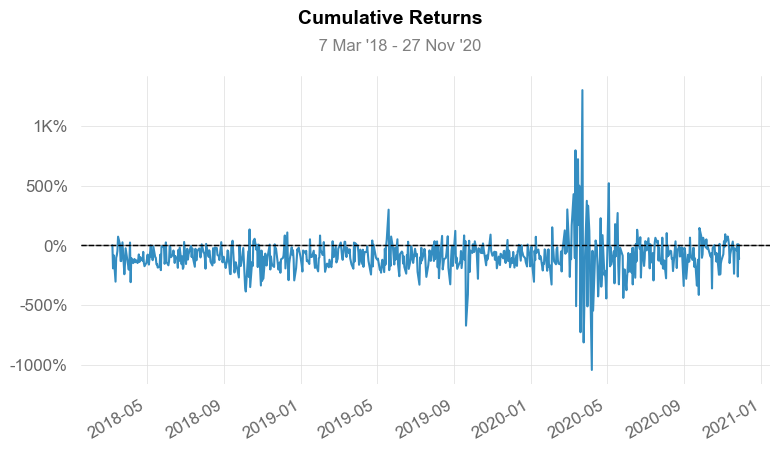

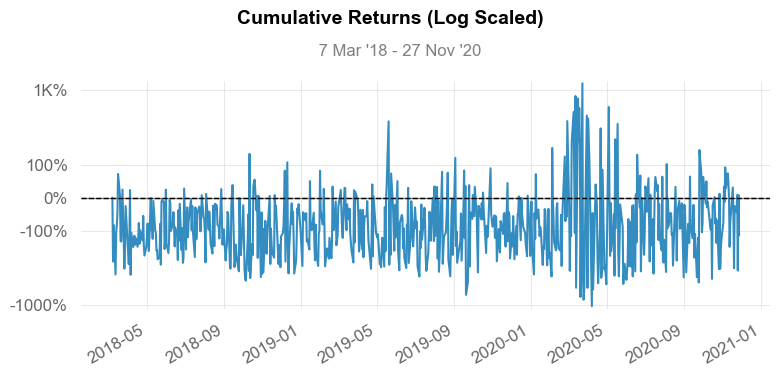

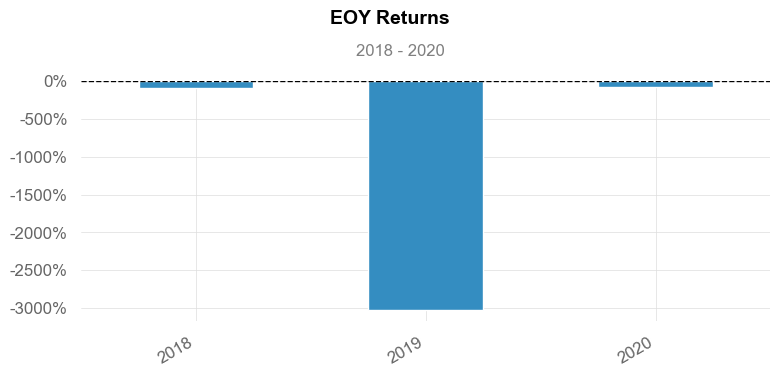

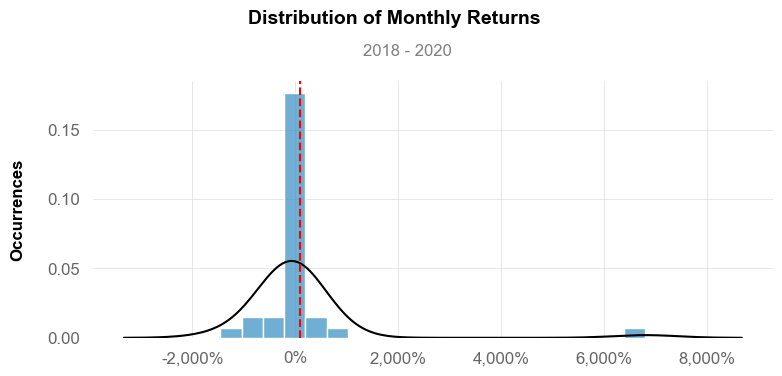

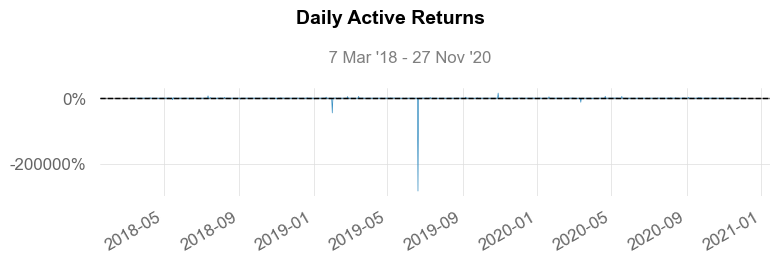

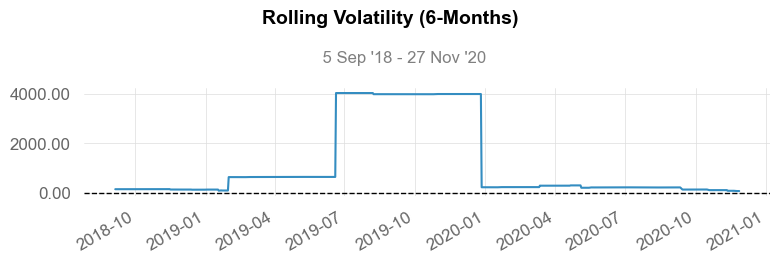

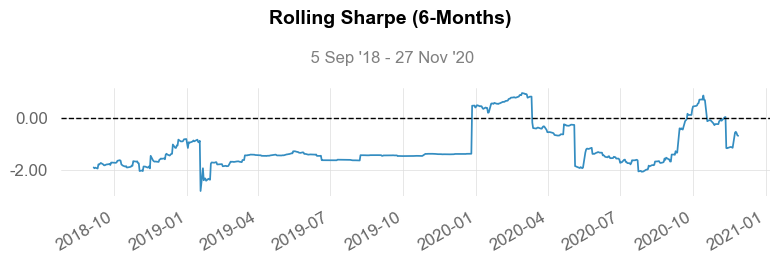

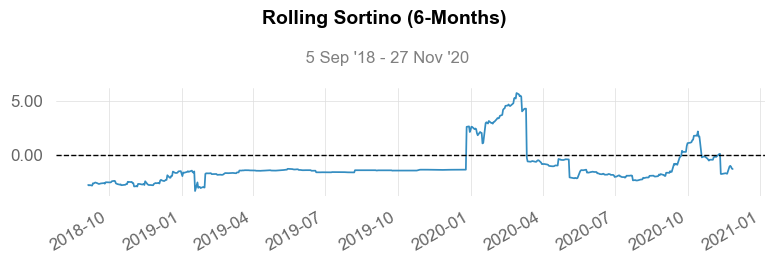

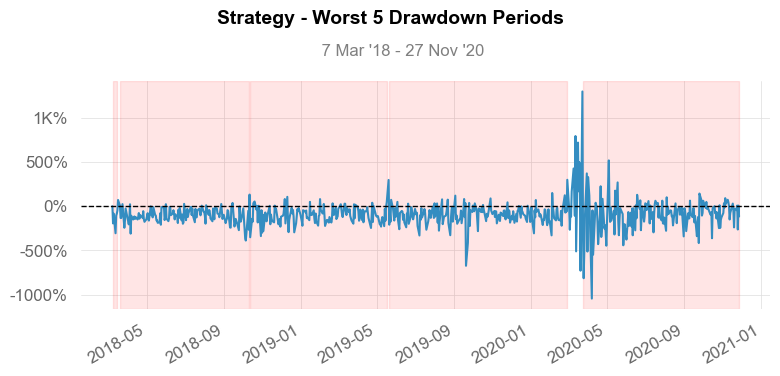

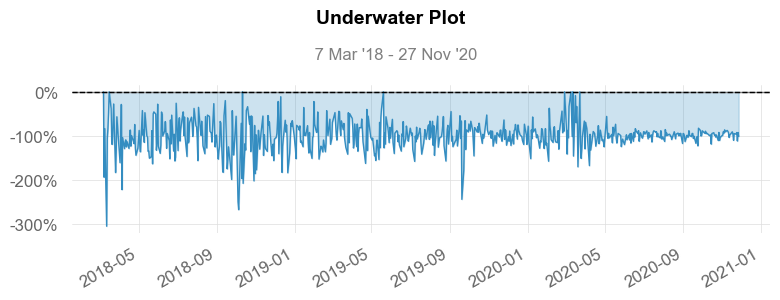

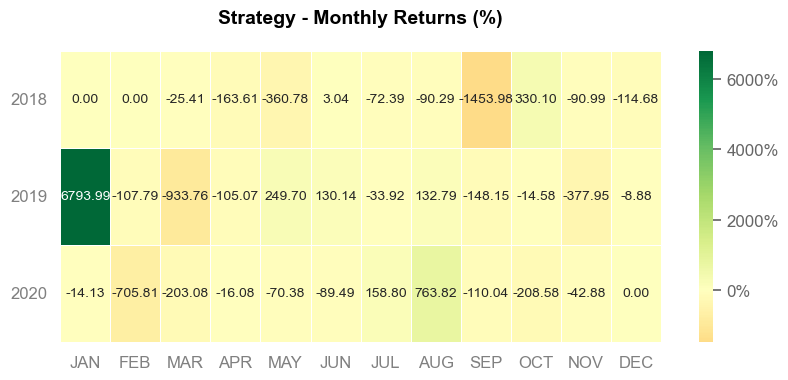

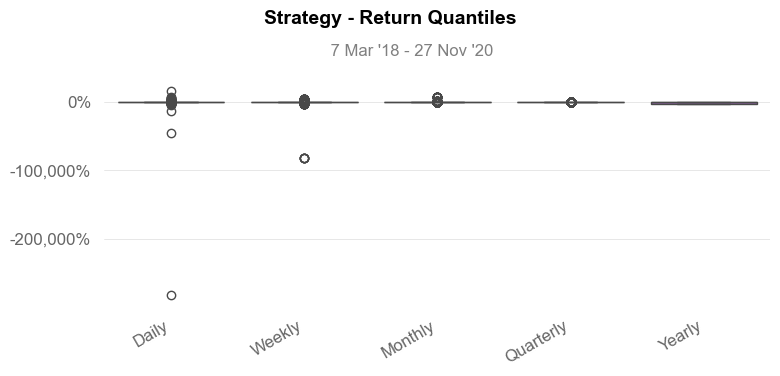

In [97]:
qs.reports.full(strategy_returns)

In [98]:
# Tradewise analysis
a = data[['Close', 'signal','position', 'strategy_equity']
         ].loc[(data['signal'] == 1) | (data['signal'] == -1)]
a

,Close,signal,position,strategy_equity
Date,,,,
2018-03-05,10358.849609,-1,-1,1.000000
2018-04-30,10739.349609,1,1,0.952320
2018-10-04,10599.250000,-1,-1,0.943633
2018-12-13,10791.549805,1,1,0.873490
2019-07-22,11346.200195,-1,-1,0.916021
2019-10-09,11313.299805,1,1,0.908864
2020-02-14,12113.450195,-1,-1,0.986788
2020-06-04,10029.099609,1,1,1.088727


In [99]:
data.tail(5)

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal,position,bnh_returns,strategy_returns,bnh_equity,strategy_equity
Date,,,,,,,,,,,,,,,
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0,1,0.005241,0.005241,1.395169,1.371971
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0,1,0.009956,0.009956,1.409060,1.385630
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0,1,-0.015071,-0.015071,1.387824,1.364748
2020-11-26,12987.000000,13018.000000,12790.400391,12906.450195,549800,12444.764323,11846.407909,12392.497675,11823.745210,0,1,0.010001,0.010001,1.401704,1.378397
2020-11-27,12968.950195,13035.299805,12914.299805,13012.049805,1162400,12503.781017,11867.381727,12444.764323,11846.407909,0,1,-0.001390,-0.001390,1.399756,1.376481


In [100]:
data.tail()

,Close,High,Low,Open,Volume,sma,lma,sma_prev_day,lma_prev_day,signal,position,bnh_returns,strategy_returns,bnh_equity,strategy_equity
Date,,,,,,,,,,,,,,,
2020-11-23,12926.450195,12968.849609,12825.700195,12960.299805,633100,12287.000000,11777.845192,12237.952381,11754.670588,0,1,0.005241,0.005241,1.395169,1.371971
2020-11-24,13055.150391,13079.099609,12978.000000,13002.599609,571900,12340.561942,11802.970595,12287.000000,11777.845192,0,1,0.009956,0.009956,1.409060,1.385630
2020-11-25,12858.400391,13145.849609,12833.650391,13130.000000,679000,12392.497675,11823.745210,12340.561942,11802.970595,0,1,-0.015071,-0.015071,1.387824,1.364748
2020-11-26,12987.000000,13018.000000,12790.400391,12906.450195,549800,12444.764323,11846.407909,12392.497675,11823.745210,0,1,0.010001,0.010001,1.401704,1.378397
2020-11-27,12968.950195,13035.299805,12914.299805,13012.049805,1162400,12503.781017,11867.381727,12444.764323,11846.407909,0,1,-0.001390,-0.001390,1.399756,1.376481


In [101]:
b = data.iloc[-1:][['Close', 'signal','position','strategy_equity']]

In [102]:
b

,Close,signal,position,strategy_equity
Date,,,,
2020-11-27,12968.950195,0,1,1.376481


In [103]:
#Squaring-off the last position
b['signal']=-1
b['position']=0

In [104]:
b

,Close,signal,position,strategy_equity
Date,,,,
2020-11-27,12968.950195,-1,0,1.376481


In [105]:
a

,Close,signal,position,strategy_equity
Date,,,,
2018-03-05,10358.849609,-1,-1,1.000000
2018-04-30,10739.349609,1,1,0.952320
2018-10-04,10599.250000,-1,-1,0.943633
2018-12-13,10791.549805,1,1,0.873490
2019-07-22,11346.200195,-1,-1,0.916021
2019-10-09,11313.299805,1,1,0.908864
2020-02-14,12113.450195,-1,-1,0.986788
2020-06-04,10029.099609,1,1,1.088727


In [106]:
a = pd.concat([a, b], axis=0)

In [107]:
a

,Close,signal,position,strategy_equity
Date,,,,
2018-03-05,10358.849609,-1,-1,1.000000
2018-04-30,10739.349609,1,1,0.952320
2018-10-04,10599.250000,-1,-1,0.943633
2018-12-13,10791.549805,1,1,0.873490
2019-07-22,11346.200195,-1,-1,0.916021
2019-10-09,11313.299805,1,1,0.908864
2020-02-14,12113.450195,-1,-1,0.986788
2020-06-04,10029.099609,1,1,1.088727
2020-11-27,12968.950195,-1,0,1.376481


## Simple returns vs Log returns: Which one to use?

In [108]:
new_data = df.copy()

In [ ]:
#Plot simple returns and log returns

new_data['log_returns'] = np.log(data['Close'] / data['Close'].shift())

new_data['simple_returns'] = data['Close'].pct_change()

new_data[['log_returns', 'simple_returns']].plot()

plt.show()

Why do we use log returns a lot in finance:

- They are a very good approximation for simple returns when the magnitude of returns is small
- They are easier to work with due to their property of additivity: the total return between time period t and t+n is simply the sum of all the returns from `t` to `t+n`
- Can use either, but be consistent when comparing performance of two or more strategies

For other pros and cons: https://quantivity.wordpress.com/2011/02/21/why-log-returns/

In [ ]:
#Differences between log and nsimple returns become apparent whne the values are large
final_price=[]
for i in range(1,201):
    final_price.append(i)
    
ls=pd.DataFrame(final_price)

ls['initial_price']=100
ls['final_price']=final_price
ls['simple_returns']=(ls['final_price']-ls['initial_price'])/ls['initial_price']
ls['log_returns']=np.log(ls['final_price']/ls['initial_price'])
ls['log_returns']=ls['log_returns'].round(2)
ls=ls.drop(0,axis=1)

In [ ]:
ls

In [ ]:
#Evaluating returns using log pricess

# Buy and hold daily log returns
data['bnh_returns'] = np.log(data['Close'] / data['Close'].shift(2))

# Strategy log returns
data['strategy_returns'] = data['bnh_returns'] * data['position'].shift(2)

In [ ]:
data.tail()

In [ ]:
data[['bnh_returns', 'strategy_returns']].cumsum().plot()

In [ ]:
print('Buy and hold returns: ', np.round(100*(data['bnh_returns'].cumsum()[-1]), 2),'%')
print('Strategy returns: ', np.round(100*(data['strategy_returns'].cumsum()[-1]), 2),'%')

<br>

## Vectorized Backtesting vs Event Driven Backtesting (using for-loops)
#### (A sneak peek into event-driven backtesting)

Why use for-loops?
- Vectorization is not always possible, especially for complex strategies with many conditions 
- Closer to 'Point in time' analysis, i.e. helps to avoid look ahead bias and hence more realistic

In [ ]:
# fetching data
DF = df.copy()

In [ ]:
# creating Indicators/MAs
m = 21
n = 63

DF['sma_fast'] = DF['Close'].rolling(window=m).mean()
DF['sma_slow'] = DF['Close'].rolling(window=n).mean()

DF['sma_fast_prev_day'] = DF['sma_fast'].shift(1)
DF['sma_slow_prev_day'] = DF['sma_slow'].shift(1)

# Getting rid of rows with NaN values
DF.dropna(inplace=True)
DF.shape

In [ ]:
DF.head()

In [ ]:
# Creating empty lists to hold values of trading price and position
trade_price = []
position = []
date = []

In [ ]:
# generating trade_price info and position using a for-loop
# iterating through every row

for i in range(len(DF)):

    if (DF['sma_fast'].iloc[i] > DF['sma_slow'].iloc[i]) and \
            (DF['sma_fast_prev_day'].iloc[i] < DF['sma_slow_prev_day'].iloc[i]):
        trade_price.append(DF['Close'].iloc[i])
        position.append(1)
        date.append(DF.index[i].date())

    elif (DF['sma_fast'].iloc[i] < DF['sma_slow'].iloc[i]) and \
            (DF['sma_fast_prev_day'].iloc[i] > DF['sma_slow_prev_day'].iloc[i]):
        trade_price.append(DF['Close'].iloc[i])
        position.append(-1)
        date.append(DF.index[i].date())

In [ ]:
trade_price

In [ ]:
position

In [ ]:
# Creating a new df to hold results
new_df = pd.DataFrame({'date': date,
                       'trade_price': trade_price,
                       'position': position})

new_df

In [ ]:
new_df.shape

In [ ]:
# extend/close the last open trade till the last date of backtesting period
closing_trade = {'date': DF.index[-1].date(),
                 'trade_price': float(DF['Close'][-1:]),
                 'position': 0}

In [ ]:
closing_trade=pd.Series(closing_trade)

In [ ]:
closing_trade=pd.DataFrame(closing_trade)

In [ ]:
closing_trade

In [ ]:
closing_trade.shape

In [ ]:
closing_trade=closing_trade.T

In [ ]:
closing_trade

In [ ]:
new_df = pd.concat([new_df,closing_trade],ignore_index=True)

In [ ]:
#For loop (event-driven)
new_df

In [ ]:
# Vectorized
a